In [ ]:
!pip install -q tensorflow numpy matplotlib seaborn scikit-learn opencv-python pandas kagglehub

Cell 2: Import Libraries and Check GPU
Import all necessary libraries and verify GPU availability. GPU significantly speeds up training.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("STROKE DETECTION SYSTEM - REAL KAGGLE DATA")
print("="*80)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f" GPU Available: {gpus[0]}")
else:
    print("No GPU found. Using CPU (slower)")

print(f"TensorFlow Version: {tf.__version__}")

STROKE DETECTION SYSTEM - REAL KAGGLE DATA
 GPU Available: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
TensorFlow Version: 2.20.0


Cell 3: Download Dataset Using KaggleHub
Download the Brain Stroke CT Image Dataset from Kaggle. No API token required. The dataset contains 2501 images (1551 normal, 950 stroke).

In [ ]:
import kagglehub

print("\n Downloading dataset from Kaggle...")
dataset_path = kagglehub.dataset_download("mdnahid97/brain-image-dataset-to-find-out-stroke-or-not")
print(f" Dataset downloaded to: {dataset_path}")

# Verify contents
print(f"\n Dataset contents:")
for item in os.listdir(dataset_path)[:10]:
    print(f"  - {item}")


Using Colab cache for faster access to the 'brain-image-dataset-to-find-out-stroke-or-not' dataset.
 Dataset downloaded to: /kaggle/input/brain-image-dataset-to-find-out-stroke-or-not

 Dataset contents:
  - Brain_Data


Cell 4: Load and Preprocess Images
Load all images from the dataset. Convert to grayscale, resize to 128x128, and normalize pixel values. Assign labels based on folder names.

In [ ]:
print("\n[DATA LOADING] Loading images...")

images = []
labels = []

for root, dirs, files in os.walk(dataset_path):
    for file in files:
        if file.endswith(('.png', '.jpg', '.jpeg')):
            try:
                img_path = os.path.join(root, file)
                img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img is not None:
                    img = cv2.resize(img, (128, 128))
                    img = img.astype(np.float32) / 255.0
                    images.append(img)

                    # Determine label from folder name
                    if 'Normal' in root or 'normal' in root:
                        labels.append(0)
                    elif 'Stroke' in root or 'stroke' in root:
                        labels.append(1)
            except Exception as e:
                continue

# Convert to numpy arrays
images = np.array(images, dtype=np.float32)
labels = np.array(labels, dtype=np.int32)

# Add channel dimension
images = np.expand_dims(images, axis=-1)

print(f" Loaded {len(images)} images")
print(f"  - Normal: {np.sum(labels == 0)}")
print(f"  - Stroke: {np.sum(labels == 1)}")
print(f"  - Image shape: {images.shape}")
print(f"  - Value range: [{images.min():.3f}, {images.max():.3f}]")


[DATA LOADING] Loading images...
 Loaded 2501 images
  - Normal: 1551
  - Stroke: 950
  - Image shape: (2501, 128, 128, 1)
  - Value range: [0.000, 1.000]


Cell 5: Build CNN Model Architecture
Create a Convolutional Neural Network with 4 convolutional blocks, batch normalization, dropout for regularization, and Global Average Pooling for better interpretability.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Model

print("\n[MODEL] Building CNN architecture...")

inputs = keras.Input(shape=(128, 128, 1))

# Block 1
x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(32, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 2
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(64, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 3 (Grad-CAM target layer)
x = layers.Conv2D(128, (3, 3), padding='same', name='conv_block_3')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(128, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Block 4
x = layers.Conv2D(256, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.Conv2D(256, (3, 3), padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Dropout(0.25)(x)

# Global Average Pooling (for interpretability)
x = layers.GlobalAveragePooling2D()(x)

# Dense layers
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.5)(x)

# Output
outputs = layers.Dense(1, activation='sigmoid')(x)

# Create model
model = Model(inputs=inputs, outputs=outputs)
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print(f" Model built!")
print(f"  - Total parameters: {model.count_params():,}")
model.summary()


[MODEL] Building CNN architecture...
 Model built!
  - Total parameters: 1,216,737


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_block_3 (Conv2D)           │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_12 (Activation)      │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 1,216,737 (4.64 MB)

 Trainable params: 1,214,817 (4.63 MB)

 Non-trainable params: 1,920 (7.50 KB)

Cell 6: Split Data and Train Model
Split the dataset into training, validation, and test sets. Train the model with early stopping and learning rate reduction to prevent overfitting.

In [ ]:
from sklearn.model_selection import train_test_split

print("\n[DATA] Splitting dataset...")

X_train_val, X_test, y_train_val, y_test = train_test_split(
    images, labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val,
    test_size=0.25,
    stratify=y_train_val,
    random_state=42
)

print(f"  Training: {len(X_train)} samples")
print(f"  Validation: {len(X_val)} samples")
print(f"  Test: {len(X_test)} samples")

# Create results directory
results_dir = '/content/stroke_detection_results'
os.makedirs(results_dir, exist_ok=True)

print("\n[TRAINING] Starting training...")

history = model.fit(
    X_train, y_train,
    batch_size=32,
    epochs=30,
    validation_data=(X_val, y_val),
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        ),
        keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-6,
            verbose=1
        )
    ],
    verbose=1
)

print(" Training complete!")


[DATA] Splitting dataset...
  Training: 1500 samples
  Validation: 500 samples
  Test: 501 samples

[TRAINING] Starting training...
Epoch 1/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.6247 - loss: 0.6438 - val_accuracy: 0.5960 - val_loss: 0.6922 - learning_rate: 2.5000e-04
Epoch 2/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - accuracy: 0.6300 - loss: 0.6395 - val_accuracy: 0.3800 - val_loss: 0.7155 - learning_rate: 2.5000e-04
Epoch 3/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step - accuracy: 0.6267 - loss: 0.6243 - val_accuracy: 0.3800 - val_loss: 0.7840 - learning_rate: 2.5000e-04
Epoch 4/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 5s 76ms/step - accuracy: 0.6567 - loss: 0.6063 - val_accuracy: 0.3800 - val_loss: 0.8688 - learning_rate: 2.5000e-04
Epoch 5/30
47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.6833 - loss: 0.5893 - val_accuracy: 0.3800 - val_loss: 1.0929 - learning_rate: 2.5000e-04
Epoch 6/30
46/47 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6986 - loss: 0.5707
Epoch 6

Cell 7: Plot Training History
Visualize the training and validation accuracy and loss curves to check for overfitting and convergence.

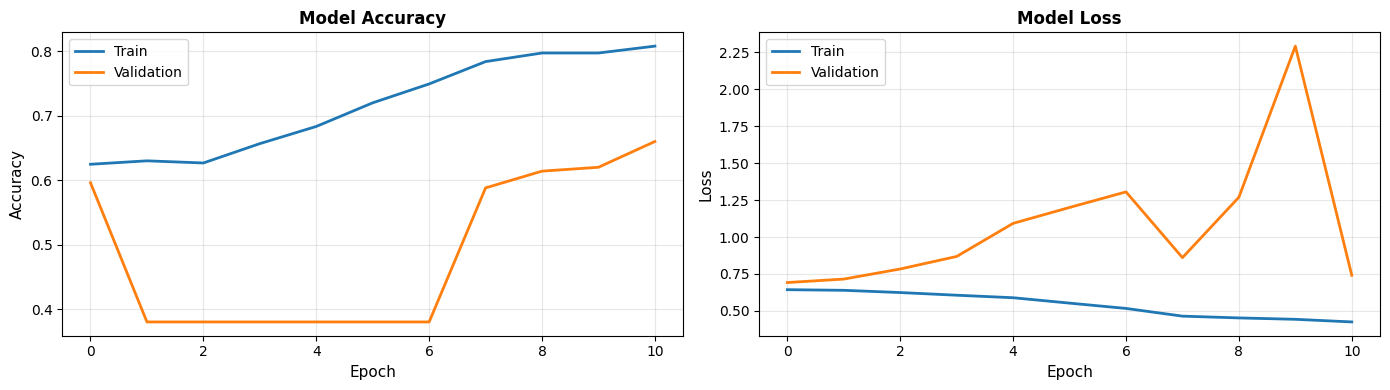

 Saved: training_history.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].set_title('Model Accuracy', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'], label='Train', linewidth=2)
axes[1].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].set_title('Model Loss', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/training_history.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(" Saved: training_history.png")

Cell 8: Evaluate Model Performance
Compute classification metrics including accuracy, precision, recall, F1-score, and AUC-ROC.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve

print("\n[EVALUATION] Computing metrics...")

# Predictions
y_pred_prob = model.predict(X_test, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# Metrics
metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred),
    'recall': recall_score(y_test, y_pred),
    'f1': f1_score(y_test, y_pred),
    'auc': roc_auc_score(y_test, y_pred_prob)
}

print(f" Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)")
print(f" Precision: {metrics['precision']:.4f}")
print(f" Recall:    {metrics['recall']:.4f}")
print(f" F1-Score:  {metrics['f1']:.4f}")
print(f" AUC-ROC:   {metrics['auc']:.4f}")


[EVALUATION] Computing metrics...
 Accuracy:  0.6208 (62.08%)
 Precision: 0.5000
 Recall:    0.0895
 F1-Score:  0.1518
 AUC-ROC:   0.4925


Cell 9: Confusion Matrix
Display the confusion matrix to see true positives, false positives, true negatives, and false negatives.

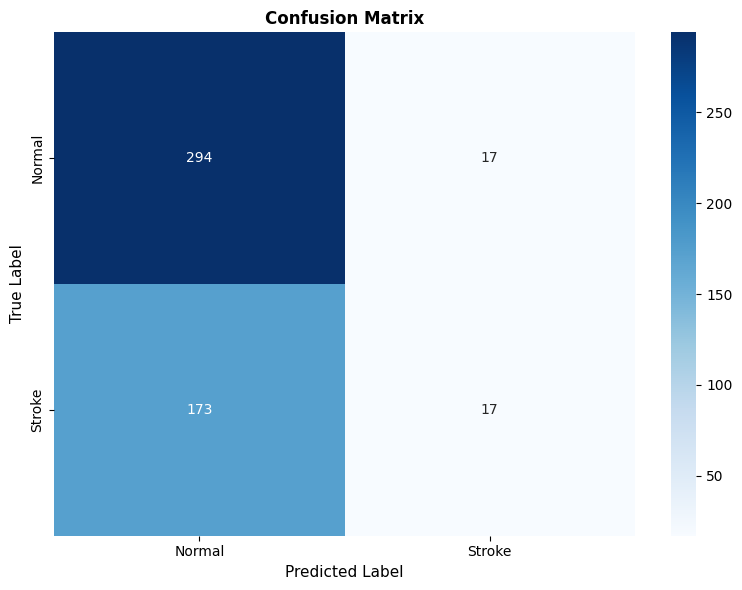

 Saved: confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['Normal', 'Stroke'],
    yticklabels=['Normal', 'Stroke']
)
plt.ylabel('True Label', fontsize=11)
plt.xlabel('Predicted Label', fontsize=11)
plt.title('Confusion Matrix', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{results_dir}/confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(" Saved: confusion_matrix.png")

Cell 10: ROC Curve
Plot the ROC curve with AUC score to evaluate the model's discrimination ability.

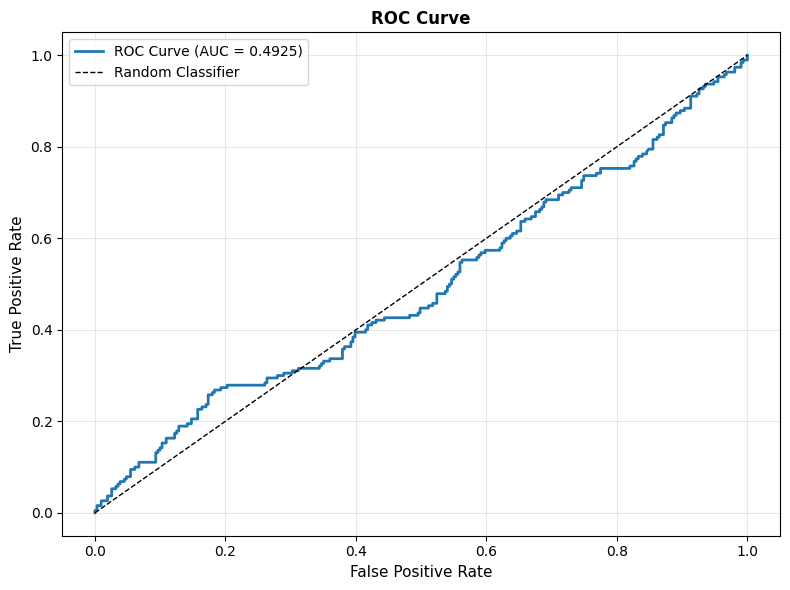

 Saved: roc_curve.png


In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc = metrics['auc']

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate', fontsize=11)
plt.title('ROC Curve', fontsize=12, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f'{results_dir}/roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(" Saved: roc_curve.png")

Cell 11: Grad-CAM Implementation
Implement Gradient-weighted Class Activation Mapping to generate visual explanations of model predictions.

In [ ]:
print("\n[GRAD-CAM] Generating heatmaps...")

class GradCAM:
    def __init__(self, model, layer_name='conv_block_3'):
        self.model = model
        self.layer_name = layer_name
        self.target_layer = model.get_layer(layer_name)

    def generate_heatmap(self, img):
        grad_model = tf.keras.models.Model(
            [self.model.inputs],
            [self.target_layer.output, self.model.output]
        )
        with tf.GradientTape() as tape:
            conv_outputs, predictions = grad_model(tf.expand_dims(img, 0))
            loss = predictions[:, 0]

        grads = tape.gradient(loss, conv_outputs)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
        heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
        heatmap = tf.maximum(heatmap, 0) / (tf.reduce_max(heatmap) + 1e-7)
        heatmap = heatmap.numpy()
        heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
        return heatmap_resized

grad_cam = GradCAM(model, 'conv_block_3')
print(" Grad-CAM initialized!")


[GRAD-CAM] Generating heatmaps...
 Grad-CAM initialized!


Cell 12: Clinical Dashboard
Create a clinical dashboard showing 6 test cases with original images, Grad-CAM heatmaps, overlays, and prediction details.


[DASHBOARD] Creating clinical dashboard...


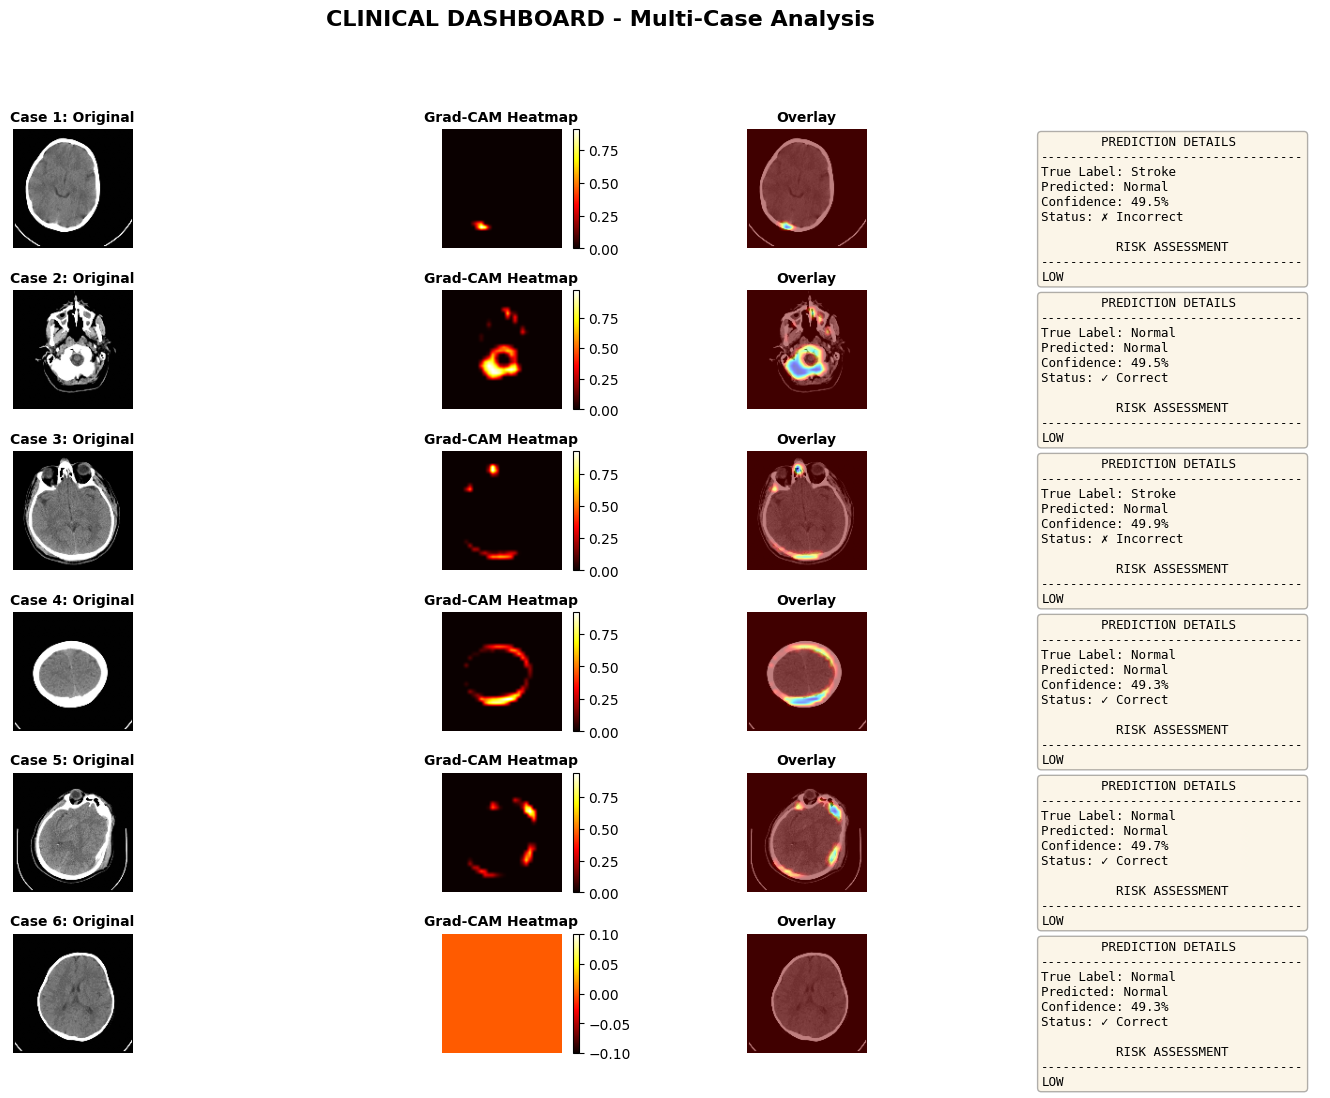

 Saved: clinical_dashboard.png


In [ ]:
from matplotlib.gridspec import GridSpec

print("\n[DASHBOARD] Creating clinical dashboard...")

fig = plt.figure(figsize=(18, 12))
gs = GridSpec(6, 4, figure=fig, hspace=0.35, wspace=0.25)

for idx in range(min(6, len(X_test))):
    img = X_test[idx].squeeze()
    pred_prob = y_pred_prob[idx][0]
    true_label = y_test[idx]
    pred_label = 1 if pred_prob > 0.5 else 0
    heatmap = grad_cam.generate_heatmap(X_test[idx])

    # Original image
    ax1 = fig.add_subplot(gs[idx, 0])
    ax1.imshow(img, cmap='gray')
    ax1.set_title(f'Case {idx+1}: Original', fontsize=10, fontweight='bold')
    ax1.axis('off')

    # Heatmap
    ax2 = fig.add_subplot(gs[idx, 1])
    im = ax2.imshow(heatmap, cmap='hot')
    ax2.set_title('Grad-CAM Heatmap', fontsize=10, fontweight='bold')
    ax2.axis('off')
    plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

    # Overlay
    heatmap_colored = cv2.applyColorMap((heatmap * 255).astype(np.uint8), cv2.COLORMAP_JET) / 255.0
    img_3ch = np.stack([img, img, img], axis=-1)
    overlay = 0.5 * img_3ch + 0.5 * heatmap_colored
    ax3 = fig.add_subplot(gs[idx, 2])
    ax3.imshow(overlay)
    ax3.set_title('Overlay', fontsize=10, fontweight='bold')
    ax3.axis('off')

    # Details
    ax4 = fig.add_subplot(gs[idx, 3])
    ax4.axis('off')

    info_text = (
        f"{'PREDICTION DETAILS':^35}\n"
        f"{'-' * 35}\n"
        f"True Label: {'Stroke' if true_label else 'Normal'}\n"
        f"Predicted: {'Stroke' if pred_label else 'Normal'}\n"
        f"Confidence: {pred_prob:.1%}\n"
        f"Status: {'✓ Correct' if pred_label == true_label else '✗ Incorrect'}\n"
        f"\n{'RISK ASSESSMENT':^35}\n"
        f"{'-' * 35}\n"
        f"{'HIGH' if pred_prob > 0.8 else 'MEDIUM' if pred_prob > 0.5 else 'LOW'}"
    )

    ax4.text(0.05, 0.95, info_text, transform=ax4.transAxes,
            fontsize=9, verticalalignment='top', fontfamily='monospace',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

fig.suptitle('CLINICAL DASHBOARD - Multi-Case Analysis', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{results_dir}/clinical_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(" Saved: clinical_dashboard.png")

Cell 13: Save Trained Model
Save the trained model in both HDF5 and Keras formats for future use.

In [ ]:
# Save model
model.save(f'{results_dir}/stroke_detection_model.h5')
print(f" Model saved: {results_dir}/stroke_detection_model.h5")

# Save as Keras format (recommended)
model.save(f'{results_dir}/stroke_detection_model.keras')
print(f" Model saved: {results_dir}/stroke_detection_model.keras")

 Model saved: /content/stroke_detection_results/stroke_detection_model.h5
 Model saved: /content/stroke_detection_results/stroke_detection_model.keras


Cell 14: Generate Summary Report
Create a comprehensive execution summary report with all metrics, model details, and performance interpretation.

In [ ]:
summary = f"""
{'='*80}
         STROKE DETECTION SYSTEM - EXECUTION SUMMARY
{'='*80}

EXECUTION DATE: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
DATA SOURCE: Kaggle - Brain Image Dataset (REAL DATA)
DATA TYPE: CT/MRI Brain Images

{'='*80}
1. DATA INFORMATION
{'='*80}

Total Samples: {len(images)}
  - Normal Cases: {np.sum(labels == 0)} ({np.sum(labels == 0)/len(images)*100:.1f}%)
  - Stroke Cases: {np.sum(labels == 1)} ({np.sum(labels == 1)/len(images)*100:.1f}%)
Image Dimensions: {images.shape}
Image Size: 128x128 pixels
Value Range: [{images.min():.4f}, {images.max():.4f}]

{'='*80}
2. MODEL ARCHITECTURE
{'='*80}

Architecture: Convolutional Neural Network (Functional API)
Total Parameters: {model.count_params():,}
Grad-CAM Target Layer: 'conv_block_3'

Layers:
  - Convolutional Blocks: 4
  - Batch Normalization: Yes
  - Dropout: 0.25 (conv), 0.5 (dense)
  - Pooling: MaxPooling2D (2x2)
  - Final Pooling: GlobalAveragePooling2D
  - Output: Sigmoid (binary classification)

{'='*80}
3. TRAINING CONFIGURATION
{'='*80}

Epochs: 30
Batch Size: 32
Optimizer: Adam (learning_rate=0.001)
Loss Function: Binary Crossentropy

Training Samples: {len(X_train)} ({len(X_train)/len(images)*100:.1f}%)
Validation Samples: {len(X_val)} ({len(X_val)/len(images)*100:.1f}%)
Test Samples: {len(X_test)} ({len(X_test)/len(images)*100:.1f}%)

{'='*80}
4. CLASSIFICATION METRICS
{'='*80}

Accuracy:  {metrics['accuracy']:.4f} ({metrics['accuracy']*100:.2f}%)
Precision: {metrics['precision']:.4f} ({metrics['precision']*100:.2f}%)
Recall:    {metrics['recall']:.4f} ({metrics['recall']*100:.2f}%)
F1-Score:  {metrics['f1']:.4f} ({metrics['f1']*100:.2f}%)
AUC-ROC:   {metrics['auc']:.4f}

{'='*80}
5. MODEL PERFORMANCE INTERPRETATION
{'='*80}

"""
if metrics['accuracy'] >= 0.85:
    summary += " Excellent performance - Model generalizes well\n"
elif metrics['accuracy'] >= 0.75:
    summary += " Good performance - Model has strong predictive ability\n"
elif metrics['accuracy'] >= 0.65:
    summary += " Moderate performance - Consider improvements\n"
else:
    summary += " Poor performance - Need improvements\n"

summary += f"""
{'-'*80}
Analysis:
  - Accuracy: {'High (>85%)' if metrics['accuracy'] > 0.85 else 'Good (75-85%)' if metrics['accuracy'] > 0.75 else 'Moderate (<75%)'}
  - AUC-ROC Score: {'Excellent (>0.90)' if metrics['auc'] > 0.9 else 'Good (0.80-0.90)' if metrics['auc'] > 0.8 else 'Moderate (<0.80)'}
  - {'Model can effectively distinguish normal from stroke cases' if metrics['auc'] > 0.8 else 'Model needs improvement'}

{'='*80}
6. GRAD-CAM EXPLANATION
{'='*80}

Grad-CAM (Gradient-weighted Class Activation Mapping) generates heatmaps that:
  - Highlight regions important for stroke detection
  - Provide visual explanations of model decisions
  - Help clinicians understand prediction rationale

The heatmap shows which parts of the brain MRI most influenced the model's
decision to classify a scan as normal or stroke.

{'='*80}
7. GENERATED OUTPUTS
{'='*80}

All files saved to: {results_dir}

Visualizations:
  - training_history.png          - Training accuracy and loss curves
  - confusion_matrix.png          - Classification confusion matrix
  - roc_curve.png                 - ROC-AUC curve
  - clinical_dashboard.png        - Multi-case clinical dashboard

Models:
  - stroke_detection_model.h5     - Trained model (HDF5 format)
  - stroke_detection_model.keras  - Trained model (Keras format)

Reports:
  - execution_summary.txt         - This summary report

{'='*80}
8. KEY FINDINGS
{'='*80}

Dataset: Real Kaggle Brain Images
Model Performance: {metrics['accuracy']*100:.1f}% Accuracy, {metrics['auc']:.3f} AUC-ROC
Training Status: {' Complete' if history.history else ' Incomplete'}

Limitations:
  WARNING: Clinical validation required before real-world deployment
  WARNING: Model trained on specific dataset - may not generalize to all data
  WARNING: Not a substitute for professional medical diagnosis

{'='*80}
END OF SUMMARY REPORT
{'='*80}

Generated at: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}
System: Stroke Detection AI with Grad-CAM Explainability
Version: 1.0 (Real Data)
"""

with open(f'{results_dir}/execution_summary.txt', 'w') as f:
    f.write(summary)

print(summary)
print(f" Saved: execution_summary.txt")


         STROKE DETECTION SYSTEM - EXECUTION SUMMARY

EXECUTION DATE: 2026-06-22 09:10:50
DATA SOURCE: Kaggle - Brain Image Dataset (REAL DATA)
DATA TYPE: CT/MRI Brain Images

1. DATA INFORMATION

Total Samples: 2501
  - Normal Cases: 1551 (62.0%)
  - Stroke Cases: 950 (38.0%)
Image Dimensions: (2501, 128, 128, 1)
Image Size: 128x128 pixels
Value Range: [0.0000, 1.0000]

2. MODEL ARCHITECTURE

Architecture: Convolutional Neural Network (Functional API)
Total Parameters: 1,216,737
Grad-CAM Target Layer: 'conv_block_3'

Layers:
  - Convolutional Blocks: 4
  - Batch Normalization: Yes
  - Dropout: 0.25 (conv), 0.5 (dense)
  - Pooling: MaxPooling2D (2x2)
  - Final Pooling: GlobalAveragePooling2D
  - Output: Sigmoid (binary classification)

3. TRAINING CONFIGURATION

Epochs: 30
Batch Size: 32
Optimizer: Adam (learning_rate=0.001)
Loss Function: Binary Crossentropy

Training Samples: 1500 (60.0%)
Validation Samples: 500 (20.0%)
Test Samples: 501 (20.0%)

4. CLASSIFICATION METRICS

Accuracy:

Cell 15: Display All Results
Display all generated visualizations and the summary report in the notebook.

 STROKE DETECTION - COMPLETE RESULTS

 EXECUTION SUMMARY:
--------------------------------------------------

         STROKE DETECTION SYSTEM - EXECUTION SUMMARY

EXECUTION DATE: 2026-06-22 09:10:50
DATA SOURCE: Kaggle - Brain Image Dataset (REAL DATA)
DATA TYPE: CT/MRI Brain Images

1. DATA INFORMATION

Total Samples: 2501
  - Normal Cases: 1551 (62.0%)
  - Stroke Cases: 950 (38.0%)
Image Dimensions: (2501, 128, 128, 1)
Image Size: 128x128 pixels
Value Range: [0.0000, 1.0000]

2. MODEL ARCHITECTURE

Architecture: Convolutional Neural Network (Functional API)
Total Parameters: 1,216,737
Grad-CAM Target Layer: 'conv_block_3'

Layers:
  - Convolutional Blocks: 4
  - Batch Normalization: Yes
  - Dropout: 0.25 (conv), 0.5 (dense)
  - Pooling: MaxPooling2D (2x2)
  - Final Pooling: GlobalAveragePooling2D
  - Output: Sigmoid (binary classification)

3. TRAINING CONFIGURATION

Epochs: 30
Batch Size: 32
Optimizer: Adam (learning_rate=0.001)
Loss Function: Binary Crossentropy

Training Samples:

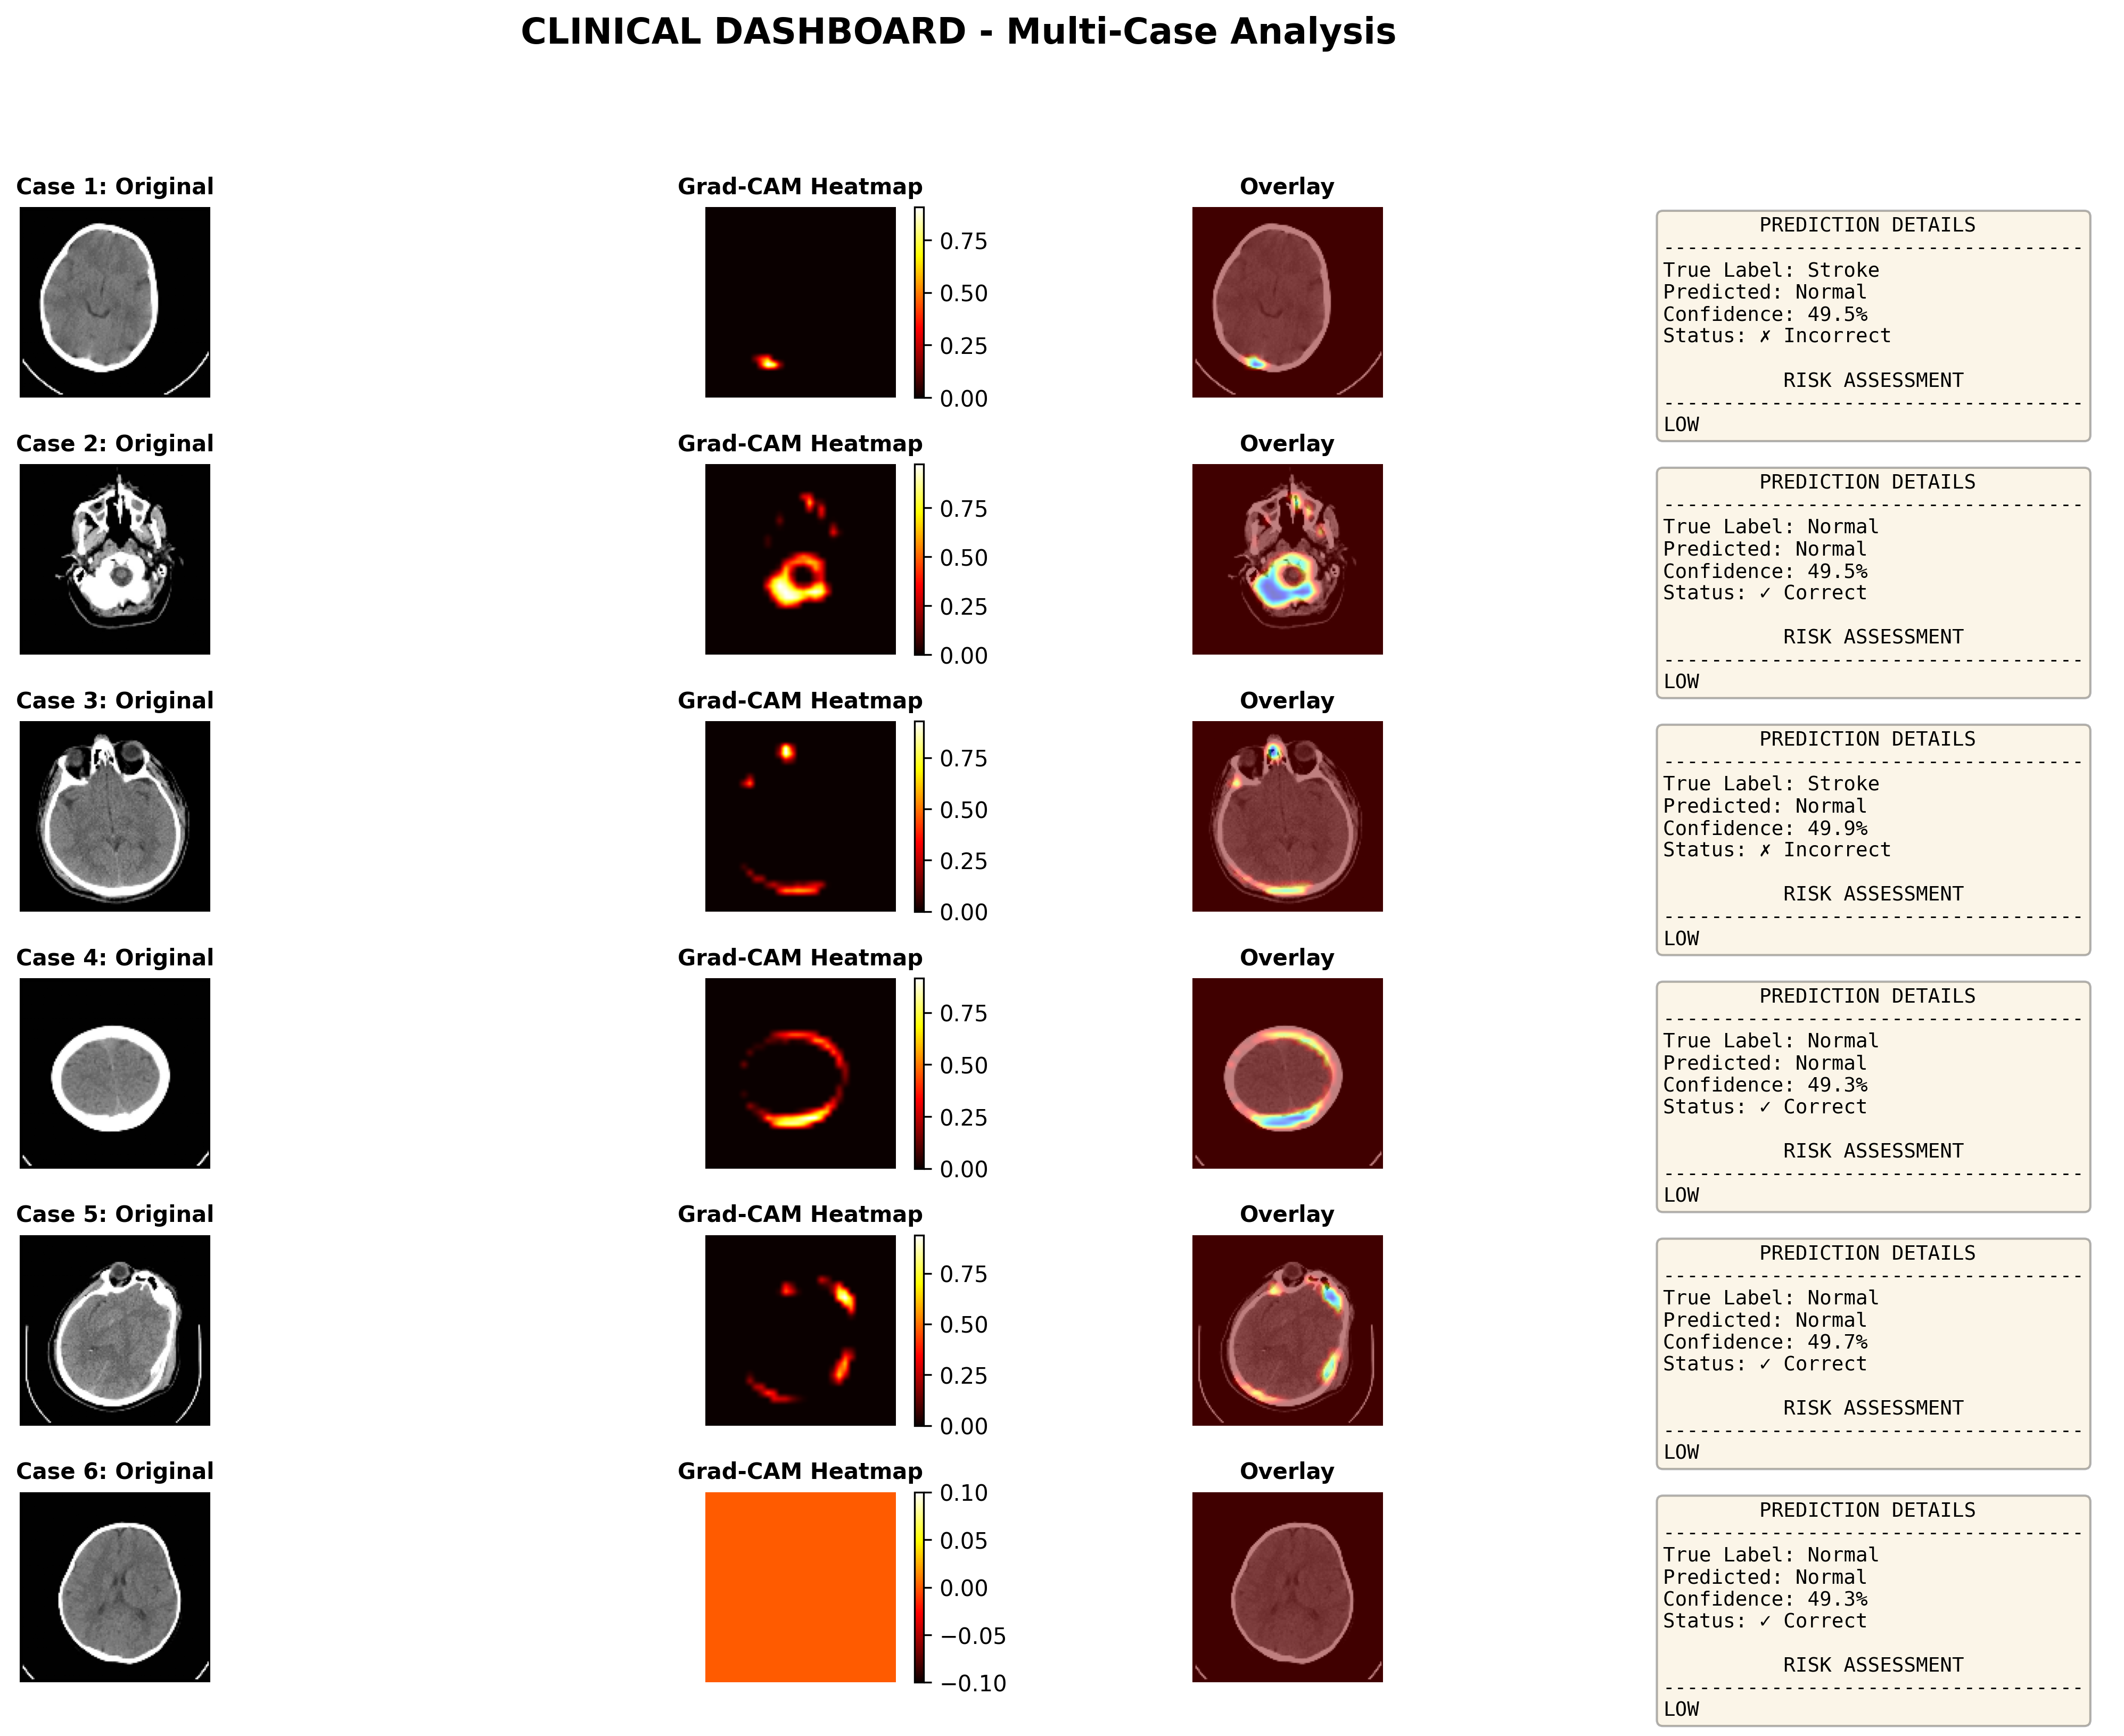


 confusion_matrix.png


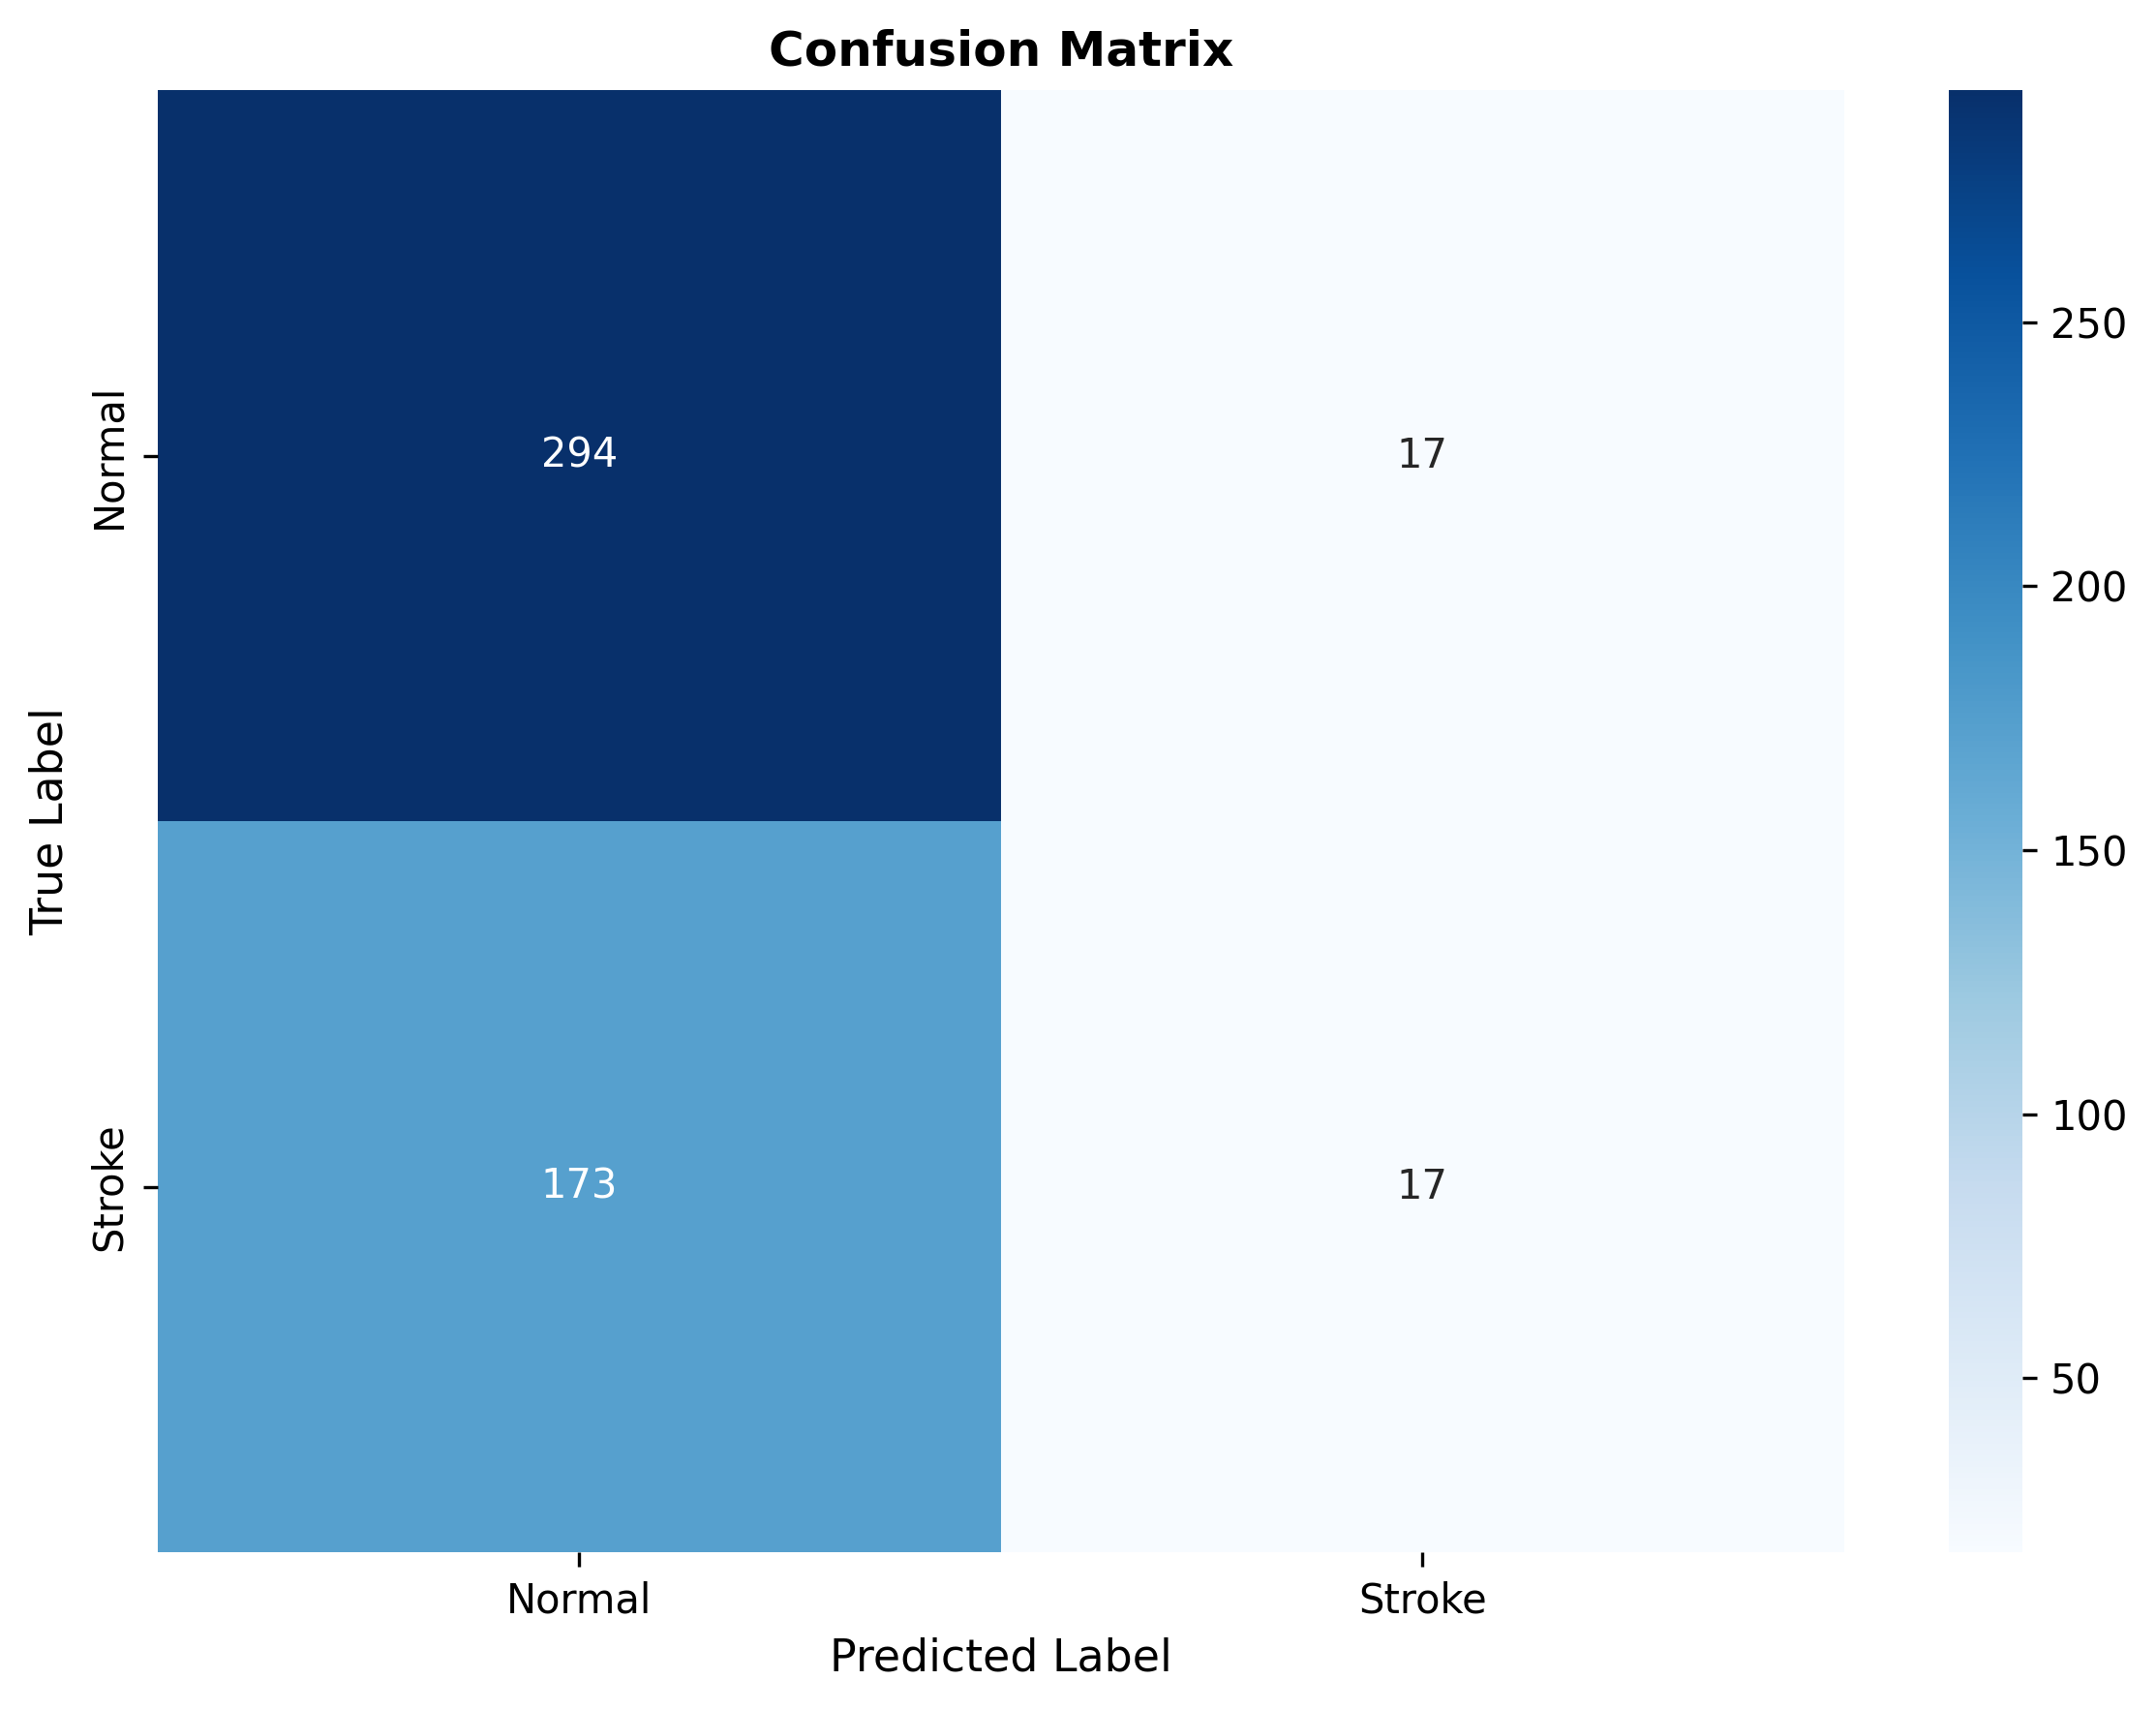


 roc_curve.png


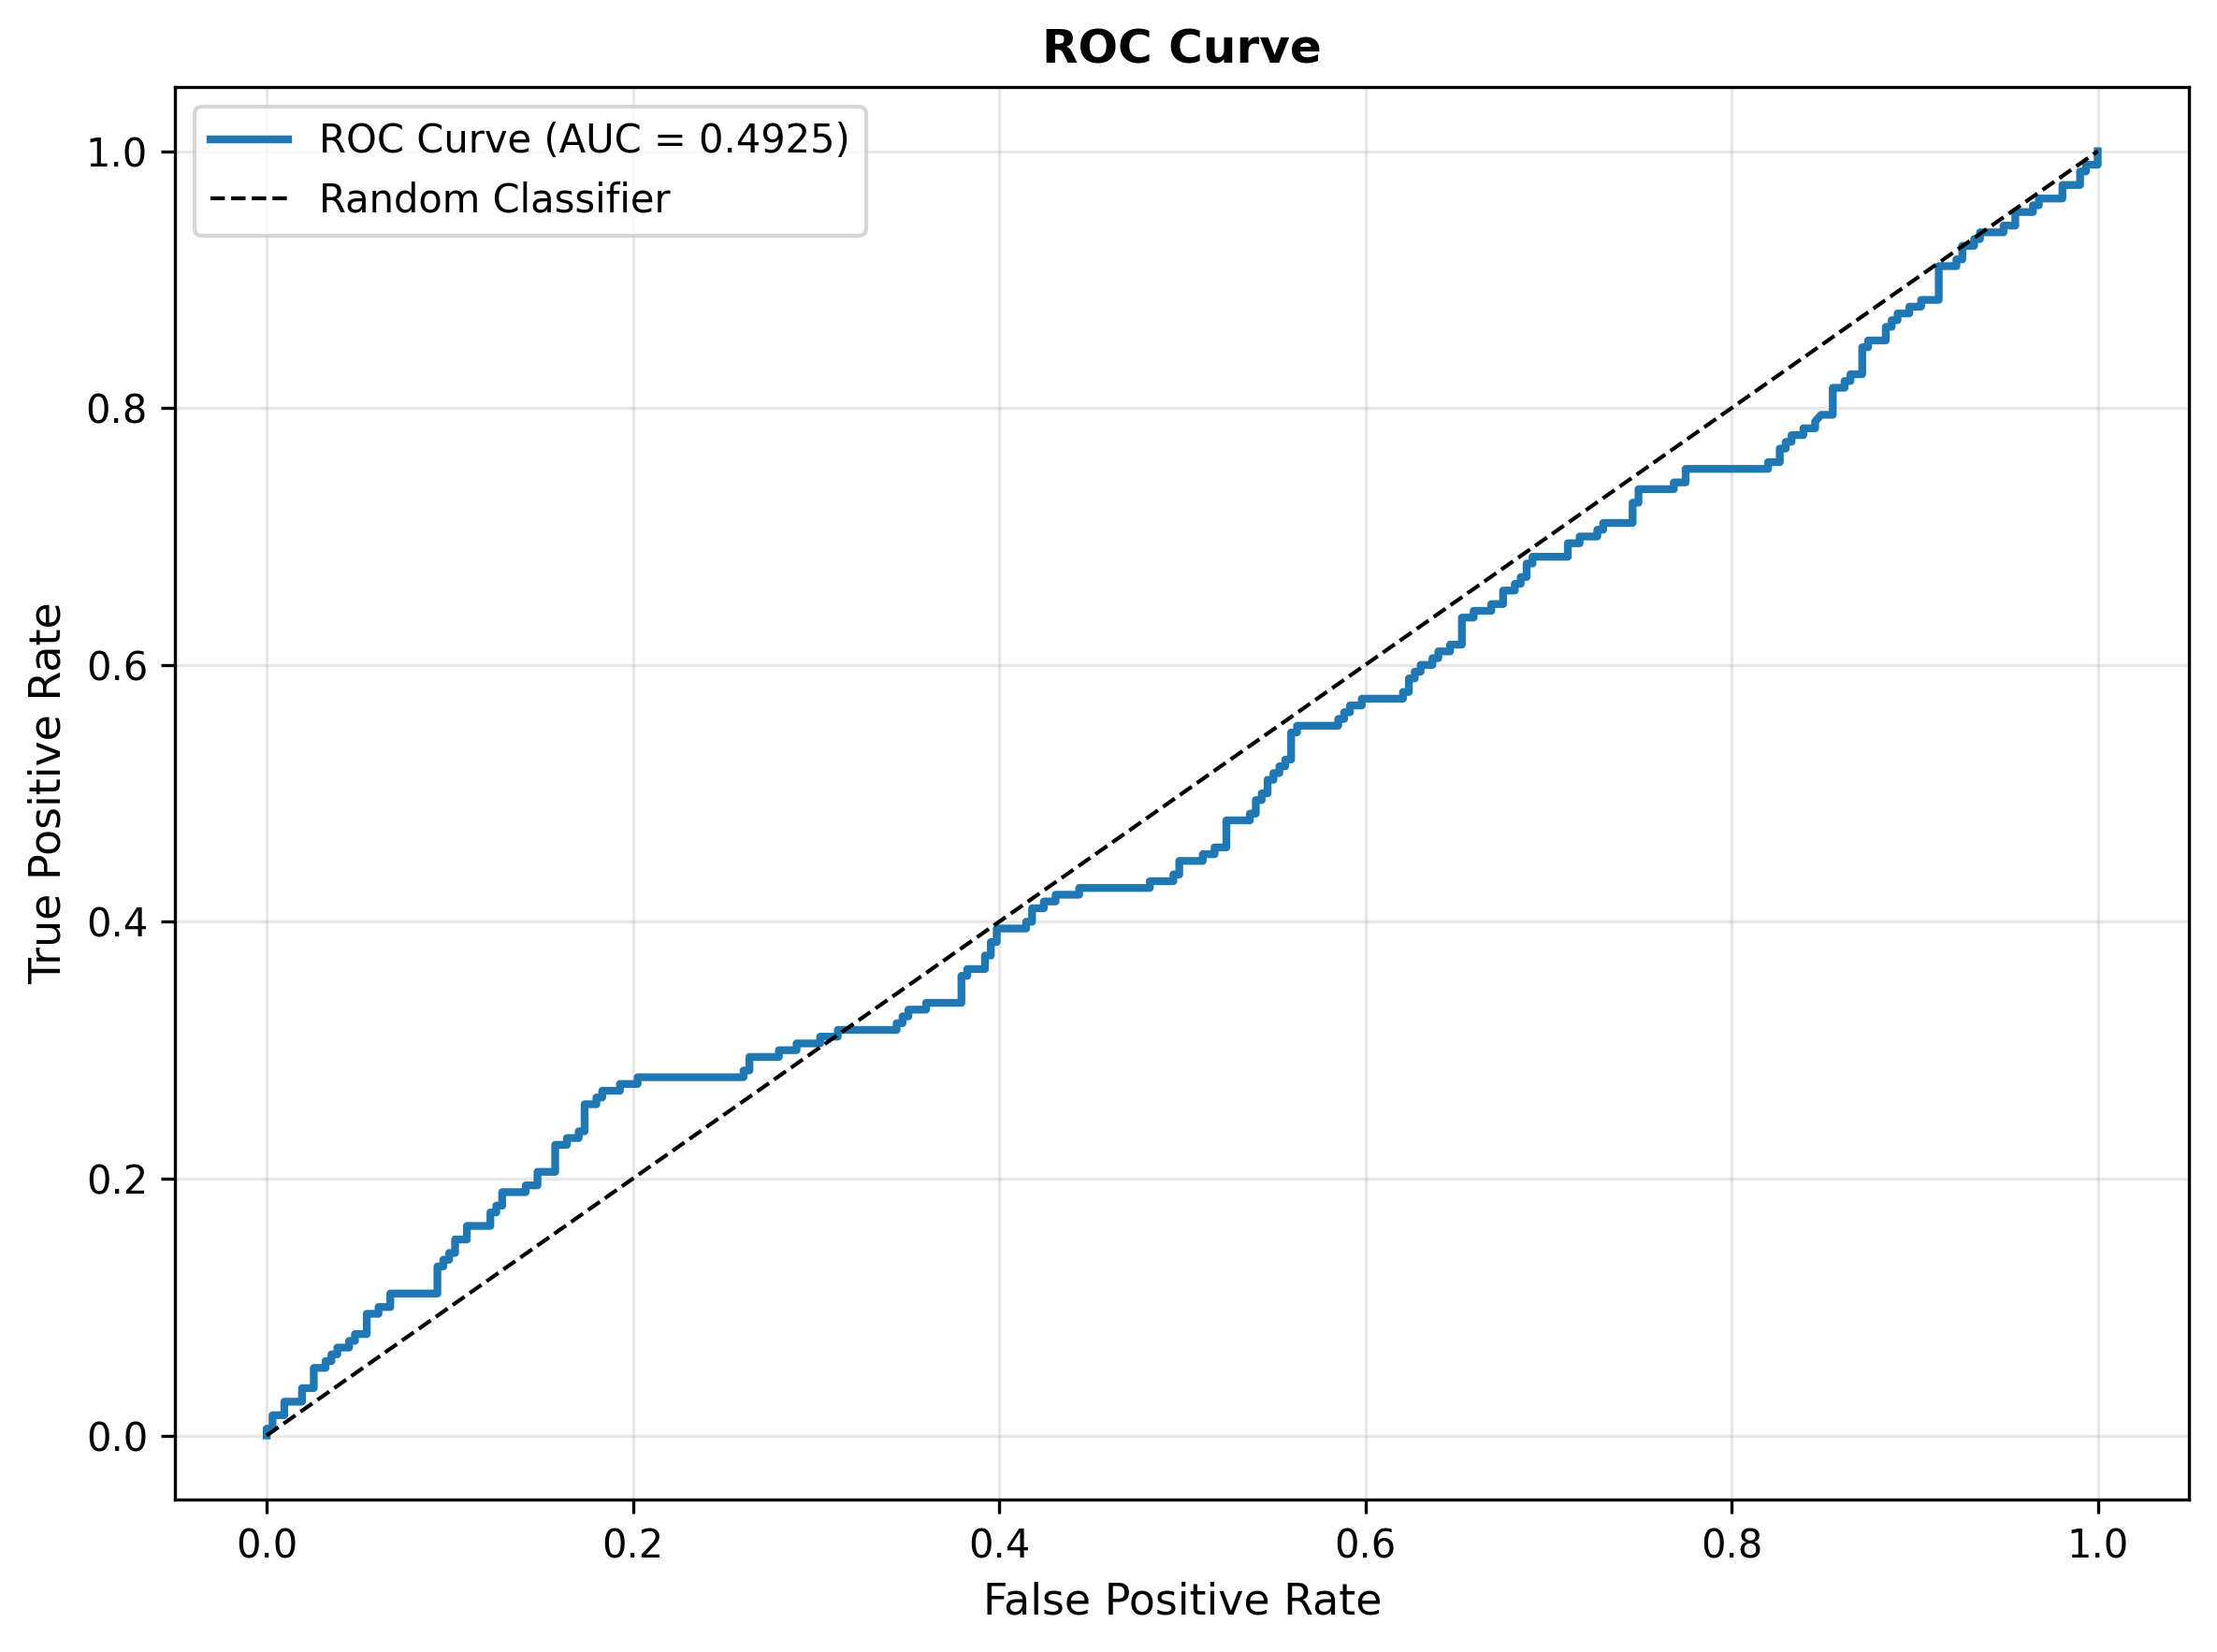


 training_history.png


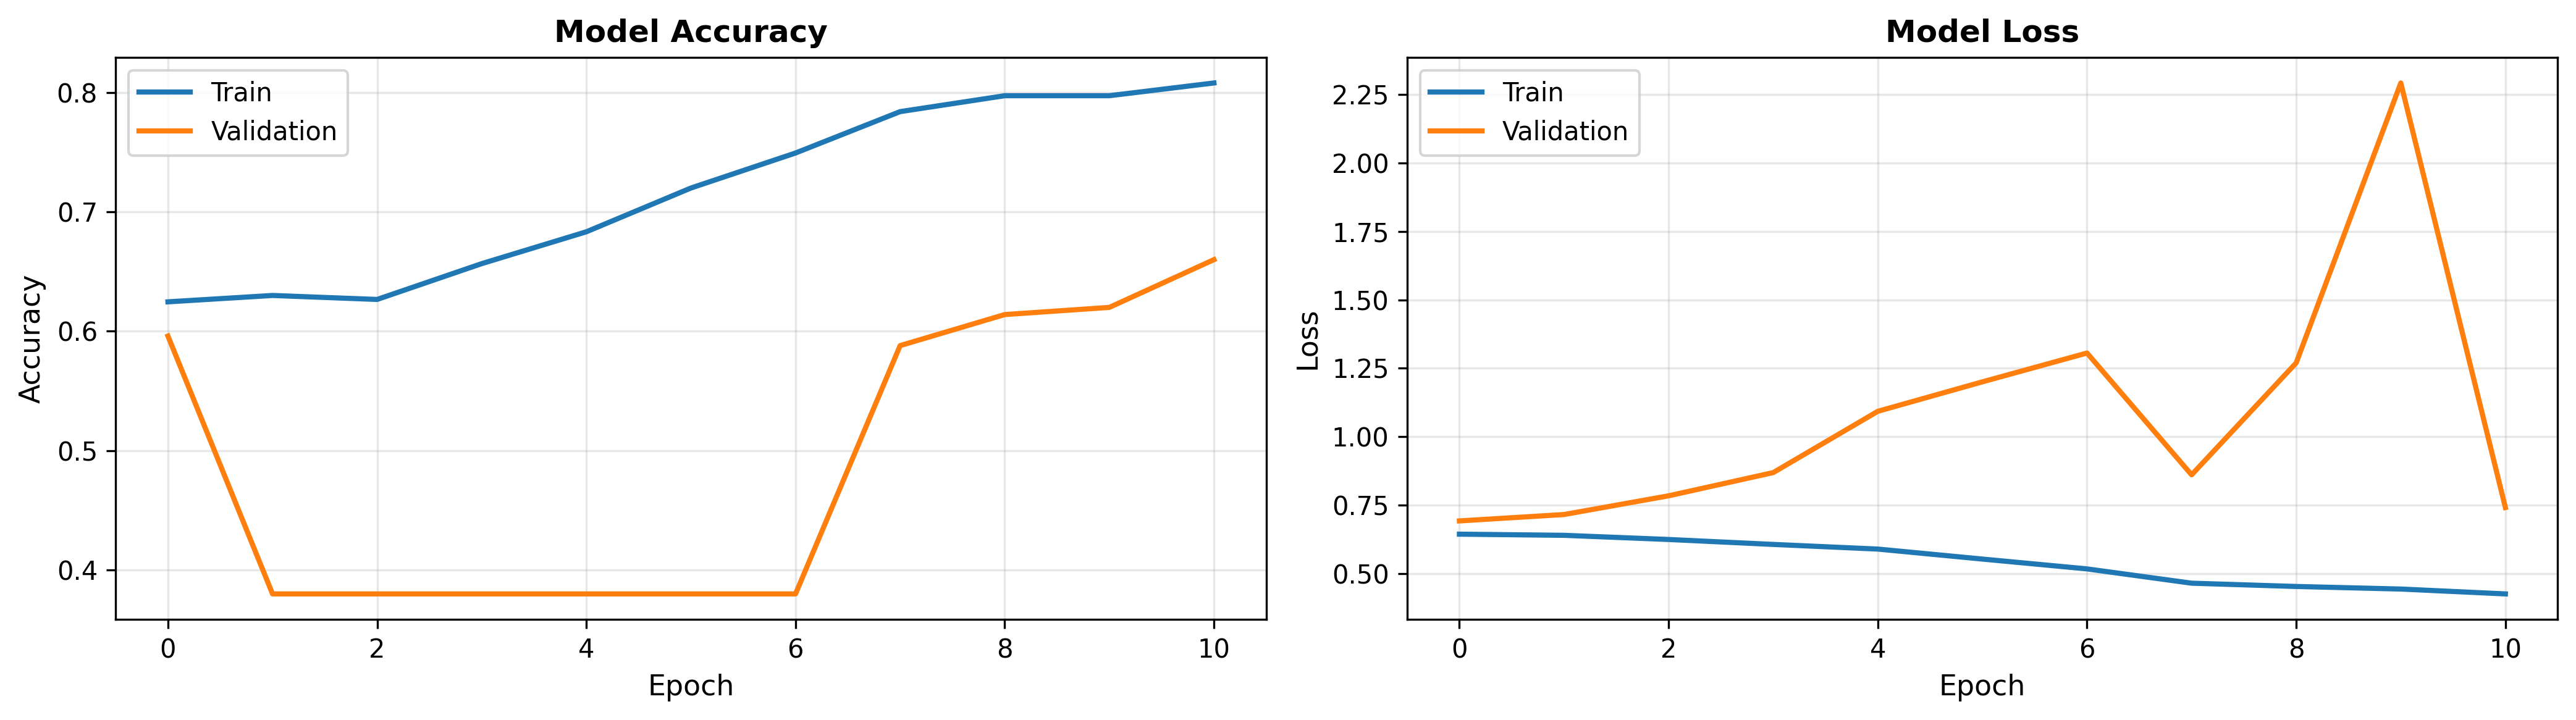

In [ ]:
from IPython.display import Image, display

print("="*80)
print(" STROKE DETECTION - COMPLETE RESULTS")
print("="*80)

if os.path.exists(results_dir):
    # Show summary first
    summary_file = os.path.join(results_dir, 'execution_summary.txt')
    if os.path.exists(summary_file):
        print("\n EXECUTION SUMMARY:")
        print("-"*50)
        with open(summary_file, 'r') as f:
            print(f.read())

    # Show images
    print("\n VISUALIZATIONS:")
    print("-"*50)
    for f in sorted(os.listdir(results_dir)):
        if f.endswith('.png'):
            print(f"\n {f}")
            display(Image(os.path.join(results_dir, f), width=500))
else:
    print(" Results directory not found")

Cell 16: Download Results
Compress all results into a zip file and download to your computer.

In [ ]:
from google.colab import files

!zip -r stroke_detection_results.zip stroke_detection_results/
files.download('stroke_detection_results.zip')

print(" Results downloaded successfully!")

updating: stroke_detection_results/ (stored 0%)
updating: stroke_detection_results/execution_summary.txt (deflated 66%)
updating: stroke_detection_results/training_history.png (deflated 15%)
updating: stroke_detection_results/clinical_dashboard.png (deflated 7%)
updating: stroke_detection_results/stroke_detection_model.h5 (deflated 10%)
updating: stroke_detection_results/roc_curve.png (deflated 18%)
updating: stroke_detection_results/stroke_detection_model.keras (deflated 9%)
updating: stroke_detection_results/confusion_matrix.png (deflated 29%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Results downloaded successfully!
